# Step 1: Put your files on Google Drive

# Step 2: Start Colab with an A100

In [1]:
!nvidia-smi

Thu Oct  1 15:26:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Step 3: Connect Drive and install

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# %cd /content/drive/MyDrive/laya_chess_clm
%cd /content/drive/MyDrive/laya_chess_clm

Mounted at /content/drive
/content/drive/MyDrive/laya_chess_clm


In [ ]:
!unzip laya_chess_20k.zip

Archive:  laya_chess_20k.zip
   creating: laya_chess_20k/
   creating: laya_chess_20k/encoder/
  inflating: laya_chess_20k/encoder/config.json  
  inflating: laya_chess_20k/eval_report.json  
  inflating: laya_chess_20k/model.safetensors  
  inflating: laya_chess_20k/rl_agent_config.json  
   creating: laya_chess_20k/tokenizer/
  inflating: laya_chess_20k/tokenizer/tokenizer_config.json  
  inflating: laya_chess_20k/tokenizer/tokenizer.json  


In [5]:
!pip install -q vllm chess pyarrow laya
!git clone -q https://github.com/Contrastive-LM/CLM.git /content/CLM && pip install -q -e /content/CLM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 17.4 MB/s eta 0:00:00
   ━━━━

# Step 4: Convert the data

In [4]:
!pkill -f "vllm serve"; echo done

^C


In [5]:
!pip uninstall -y torchaudio

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [6]:
!python -c "import torch, torchvision; print(torch.__version__, torch.version.cuda, torchvision.__version__, torch.cuda.is_available())"

2.13.0+cu130 13.0 0.28.0+cu130 True


In [ ]:
!python clm_chess.py convert --data chess_20k.jsonl chess_extra_10k.jsonl --out clm_chess_data

Wrote 17847 train and 924 test questions to clm_chess_data/all/ (11249 positions skipped: all moves equal) in 84s


# Step 5: Start Qwen3-8B

In [17]:
!nohup vllm serve Qwen/Qwen3-8B --served-model-name qwen3-8b --runner pooling --max-model-len 2048 --port 8090 --gpu-memory-utilization 0.5 > /content/vllm.log 2>&1 &

In [18]:
!for i in $(seq 1 90); do curl -s localhost:8090/health >/dev/null && echo READY && break; pgrep -f "vllm serve" >/dev/null || { echo "SERVER STOPPED"; break; }; sleep 10; done; tail -15 /content/vllm.log

READY
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /ping, Methods: GET
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /ping, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /invocations, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /pooling, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /v1/embeddings, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /v2/embed, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /score, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /v1/score, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /rerank, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /v1/rerank, Methods: POST
(APIServer pid=24562) INFO 10-01 15:52:42 [launcher.py:70] Route: /v2/rerank, Methods: POS

In [19]:
!curl -s localhost:8090/v1/embeddings -H "Content-Type: application/json" -d '{"model":"qwen3-8b","input":["hello"]}' | python -c "import sys, json; print(len(json.load(sys.stdin)['data'][0]['embedding']))"

4096


# Step 6: Train CLM's heads

In [ ]:
!cd /content/CLM && python train/finetune.py --task choice --data /content/drive/MyDrive/laya_chess_clm/clm_chess_data --workflow all --init-ckpt "$(clm-download)" --out-dir /content/drive/MyDrive/laya_chess_clm/runs/chess --embed-url http://127.0.0.1:8090/v1/embeddings --served-model-name qwen3-8b --loss softce --targets soft --embed-cache /content/drive/MyDrive/laya_chess_clm/embed_cache


CLM_v0.1-8B.pt: downloading bytes:  87% 66.0M/75.6M [00:01<00:00, 70.3MB/s, 5.03MB/s  ]
CLM_v0.1-8B.pt: downloading bytes: 100% 71.3M/71.3M [00:01<00:00, 36.8MB/s, 6.64MB/s  ]
CLM_v0.1-8B.pt: reconstructing file: 100% 75.6M/75.6M [00:01<00:00, 39.0MB/s, 7.18MB/s  ]
[choice] /content/drive/MyDrive/laya_chess_clm/clm_chess_data [all] rows train 16062 val 1785 test 924 | questions train 16062 val 1785 test 924
[choice] embedding 48001 unique texts
[embed] server 64/48001
[embed] server 3264/48001
[embed] server 6464/48001
[embed] server 9664/48001
[embed] server 12864/48001
[embed] server 16064/48001
[embed] server 19264/48001
[embed] server 22464/48001
[embed] server 25664/48001
[embed] server 28864/48001
[embed] server 32064/48001
[embed] server 35264/48001
[embed] server 38464/48001
[embed] server 41664/48001
[embed] server 44864/48001
[embed] server 48001/48001
[choice] warm start /root/.cache/clm/CLM_v0.1-8B.pt {'width': 1536, 'depth': 3, 'activation': 'gelu', 'layernorm': True, 're

# Step 7: Serve the model and evaluate it

In [ ]:
!nohup clm-serve --model chess=/content/drive/MyDrive/laya_chess_clm/runs/chess/best_head.pt --no-ui > /content/clm.log 2>&1 &

In [ ]:
!for i in $(seq 1 30); do curl -s localhost:8700/health >/dev/null && echo READY && break; sleep 5; done; tail -5 /content/clm.log

READY
[clm] models ['clm-latest', 'chess', 'clm-raw'] on cuda
[clm] embedder http://127.0.0.1:8090/v1/embeddings (qwen3-8b) up; auth off
[clm] vector cache 848.1 MB reserved on cuda (362,354x512d + 6,470x4096d)
[clm] POST http://0.0.0.0:8700/v1/systemone


In [ ]:
!python clm_chess.py evaluate --data chess_20k.jsonl chess_extra_10k.jsonl --model chess --positions 300 --report runs/eval_clm_chess.json

  50/300 positions, 6s
  100/300 positions, 11s
  150/300 positions, 16s
  200/300 positions, 22s
  250/300 positions, 26s
  300/300 positions, 30s
{
  "model": "chess",
  "positions": 300,
  "top1_match": 0.5833333333333334,
  "avg_expected_score_lost": 0.09836500000000002,
  "random_move_expected_score_lost": 0.23087422684377457,
  "avg_value_lost": 0.14656217192813753,
  "random_move_value_lost": 0.3373801529775655
}


In [ ]:
!python clm_chess.py evaluate --data chess_20k.jsonl chess_extra_10k.jsonl --laya-path laya_chess_20k --positions 300 --report runs/eval_laya_20k.json

[laya] loaded Laya fine-tuned (laya_chess_20k) on cuda in 7.7s (question: 'win')
  50/300 positions, 8s
  100/300 positions, 15s
  150/300 positions, 20s
  200/300 positions, 27s
  250/300 positions, 33s
  300/300 positions, 39s
{
  "model": "Laya fine-tuned (laya_chess_20k)",
  "positions": 300,
  "top1_match": 0.5333333333333333,
  "avg_expected_score_lost": 0.14596499999999998,
  "random_move_expected_score_lost": 0.23087422684377457,
  "avg_value_lost": 0.2148313340078278,
  "random_move_value_lost": 0.3373801529775655
}


In [ ]:
!python clm_chess.py evaluate --data chess_20k.jsonl chess_extra_10k.jsonl --positions 300 --report runs/eval_clm_original.json

  50/300 positions, 1s
  100/300 positions, 1s
  150/300 positions, 2s
  200/300 positions, 2s
  250/300 positions, 3s
  300/300 positions, 3s
{
  "model": "CLM (server default)",
  "positions": 300,
  "top1_match": 0.39666666666666667,
  "avg_expected_score_lost": 0.21923500000000004,
  "random_move_expected_score_lost": 0.23087422684377457,
  "avg_value_lost": 0.31122490006767933,
  "random_move_value_lost": 0.3373801529775655
}


# Step 8: Play matches

In [ ]:
!python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent random --log-dir runs/arena_clm_vs_random

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_clm_vs_random/
Command: python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent random --log-dir runs/arena_clm_vs_random
[clm] using http://127.0.0.1:8700 (model: chess)
   [CLM (chess)] 20 moves in 0.04s | top: e4 0.106, d4 0.105, Nf3 0.078, e3 0.067, Nc3 0.065 | spread 0.083
   [CLM (chess)] 30 moves in 0.04s | top: d4 0.075, e5 0.065, Nf3 0.062, Nc3 0.053, c4 0.049 | spread 0.065
   [CLM (chess)] 37 moves in 0.04s | top: e5 0.058, Nf3 0.052, d5 0.051, Nc3 0

In [ ]:
!python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent clm --log-dir runs/arena_clm_ft_vs_orig

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_clm_ft_vs_orig/
Command: python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent clm --log-dir runs/arena_clm_ft_vs_orig
[clm] using http://127.0.0.1:8700 (model: chess)
[clm] using http://127.0.0.1:8700 (model: server default)
Each game starts with 4 random moves
   [CLM (chess)] 28 moves in 0.09s | top: Bxh8 0.073, d4 0.068, e4 0.065, Nf3 0.059, Nc3 0.050 | spread 0.056
   [CLM (original)] 29 moves in 0.04s | top: Bf5 0.147, Bg7 0.137, Bh3 0.124, Be6 0.084, B

In [ ]:
!python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent laya --opponent-laya-path laya_chess_20k --log-dir runs/arena_clm_vs_laya

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_clm_vs_laya/
Command: python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent laya --opponent-laya-path laya_chess_20k --log-dir runs/arena_clm_vs_laya
[clm] using http://127.0.0.1:8700 (model: chess)
[laya] loaded Laya fine-tuned (laya_chess_20k) on cuda in 7.6s (question: 'win')
Each game starts with 4 random moves
   [CLM (chess)] 28 moves in 0.04s | top: Bxh8 0.073, d4 0.068, e4 0.065, Nf3 0.059, Nc3 0.050 | spread 0.056
[laya] input is 241 tokens (checkpoi

# Step 9: Fine-tune Laya v2 (rule facts + relative target)

Same data as CLM (`chess_20k.jsonl` + `chess_extra_10k.jsonl`), starting from the round-1 model `laya_chess_20k`:

* `--rules`: every input includes the rule facts (draw rules, material, repetition), like CLM's
* `--target best`: the relative target ("is this one of the best moves?"), using centipawn scores where the data has them

**Before running:** upload the latest `train_laya_chess.py` and `laya_player.py` to this Drive folder (replace the old copies). The check below confirms you have them.

In [ ]:
!grep -c "chess_rule_facts" train_laya_chess.py laya_player.py

train_laya_chess.py:2
laya_player.py:1


Both counts must be **above 0**. If either shows `0`, that file is an older version: upload the latest one and rerun the check.

### Free the GPU
The Qwen3-8B and CLM servers hold about 21 GB of this A100's 40 GB. Stop them during training (they are restarted in Step 11 for the matches):

In [ ]:
!pkill -f "vllm serve"; pkill -f clm-serve; sleep 5; nvidia-smi --query-gpu=memory.used,memory.total --format=csv

^C


Memory used should drop to near 0 MiB.

### Smoke test (a few minutes)
Checks the whole pipeline before the long run. It should end with `Fine-tuned model saved`.

In [ ]:
!python train_laya_chess.py --data chess_20k.jsonl chess_extra_10k.jsonl --rules --target best --base laya_chess_20k --out runs/laya_smoke --smoke

Base model: laya_chess_20k | max_len 512 | head_max_len 192 | device cuda | 1 process(es)
Question: 'best_rules' | target: best (tau 0.1) | rule facts: on
  chess_20k.jsonl: 8801 usable positions
  chess_extra_10k.jsonl: 9970 usable positions
Positions: train 30, val 882, test 924
Prepared inputs in 1s
Training items: 119 | tokens per item: median 412, max 433 (limit 512)
Before training: {'positions': 5, 'top1_match': 0.4, 'avg_expected_score_lost': 0.2914, 'random_move_expected_score_lost': 0.19728768188333407, 'avg_value_lost': 0.19690747097735295, 'random_move_value_lost': 0.16440974768579544} (4s)
Training 1 epoch(s), 119 items per process, 30 optimizer steps
/content/drive/MyDrive/laya_chess_clm/train_laya_chess.py:445: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first va

### Full training (roughly 1–2 hours on an A100)
Near the top, check for: `Question: 'best_rules' | target: best (tau 0.1) | rule facts: on`.
The ETA appears after 50 steps. A checkpoint is saved to Drive after every epoch (`runs/laya_chess_v2/checkpoint_latest`, plus `checkpoint_best`), so a disconnect costs at most one epoch. Keep this tab open.

In [ ]:
!rm -rf runs/laya_smoke
!python train_laya_chess.py --data chess_20k.jsonl chess_extra_10k.jsonl --rules --target best --base laya_chess_20k --out runs/laya_chess_v2 --epochs 2 --eval-positions 300 --micro-batch 16 --grad-accum 2

Base model: laya_chess_20k | max_len 512 | head_max_len 192 | device cuda | 1 process(es)
Question: 'best_rules' | target: best (tau 0.1) | rule facts: on
  chess_20k.jsonl: 8801 usable positions
  chess_extra_10k.jsonl: 9970 usable positions
Positions: train 16965, val 882, test 924
Prepared inputs in 248s
Training items: 133431 | tokens per item: median 409, max 450 (limit 512)
Before training: {'positions': 300, 'top1_match': 0.4866666666666667, 'avg_expected_score_lost': 0.172295, 'random_move_expected_score_lost': 0.2771196455924085, 'avg_value_lost': 0.23562839801115734, 'random_move_value_lost': 0.41595895936711746} (55s)
Training 2 epoch(s), 133431 items per process, 8340 optimizer steps
/content/drive/MyDrive/laya_chess_clm/train_laya_chess.py:445: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result 

In [ ]:
# import time
# from google.colab import drive, runtime
# time.sleep(60)
# drive.flush_and_unmount()
# runtime.unassign()

In [ ]:
import json
r = json.load(open("runs/laya_chess_v2/eval_report.json"))
for m in r.get("per_epoch_val", []):
    print(f"epoch {m['epoch']}: expected score lost {m['avg_expected_score_lost']:.4f}, value lost {m['avg_value_lost']:.4f}")
print("after (test):", {k: round(v, 4) for k, v in r["after_test"].items() if isinstance(v, float)})
print("calibration temperature:", round(r["noul_temperature"], 2))

epoch 1: expected score lost 0.1697, value lost 0.2541
epoch 2: expected score lost 0.1295, value lost 0.1899
after (test): {'top1_match': 0.5133, 'avg_expected_score_lost': 0.1309, 'random_move_expected_score_lost': 0.2663, 'avg_value_lost': 0.1852, 'random_move_value_lost': 0.381}
calibration temperature: 1.24


In [ ]:
!ls runs/eval_laya_v2.json

ls: cannot access 'runs/eval_laya_v2.json': No such file or directory


# Step 10: Evaluate Laya v2 on the same 300 positions

Same positions as the CLM and round-1 Laya evaluations above, so all numbers are directly comparable. Laya v2 gets its rule facts automatically.

In [ ]:
!python clm_chess.py evaluate --data chess_20k.jsonl chess_extra_10k.jsonl --laya-path runs/laya_chess_v2 --positions 300 --report runs/eval_laya_v2.json

[laya] loaded Laya fine-tuned (laya_chess_v2) +rules on cuda in 38.3s (question: 'best_rules')
  50/300 positions, 12s
  100/300 positions, 21s
  150/300 positions, 30s
  200/300 positions, 39s
  250/300 positions, 48s
  300/300 positions, 57s
{
  "model": "Laya fine-tuned (laya_chess_v2) +rules",
  "positions": 300,
  "top1_match": 0.5766666666666667,
  "avg_expected_score_lost": 0.10330000000000003,
  "random_move_expected_score_lost": 0.23087422684377457,
  "avg_value_lost": 0.15887407220771904,
  "random_move_value_lost": 0.3373801529775655
}


If the report in `runs/laya_chess_v2/eval_report.json` shows an earlier epoch was best (`per_epoch_val`), also evaluate `runs/laya_chess_v2/checkpoint_best` the same way.

### Comparison table

In [ ]:
import json, os
reports = [("Original CLM (zero-shot)", "runs/eval_clm_original.json"),
           ("Laya round 1", "runs/eval_laya_20k.json"),
           ("Laya v2", "runs/eval_laya_v2.json"),
           ("Fine-tuned CLM", "runs/eval_clm_chess.json")]
print(f"{'model':28s} {'top1':>6s} {'exp. score lost':>16s} {'value lost':>11s} {'vs random':>10s}")
for name, path in reports:
    if not os.path.exists(path):
        print(f"{name:28s} (no report yet)")
        continue
    r = json.load(open(path))
    cut = 1 - r["avg_expected_score_lost"] / r["random_move_expected_score_lost"]
    print(f"{name:28s} {r['top1_match']:6.1%} {r['avg_expected_score_lost']:16.3f} {r['avg_value_lost']:11.3f} {cut:10.0%}")
print("Random move:", round(r["random_move_expected_score_lost"], 3), "expected score lost")

model                          top1  exp. score lost  value lost  vs random
Original CLM (zero-shot)      39.7%            0.219       0.311         5%
Laya round 1                  53.3%            0.146       0.215        37%
Laya v2                       57.7%            0.103       0.159        55%
Fine-tuned CLM                58.3%            0.098       0.147        57%
Random move: 0.231 expected score lost


# Step 11: Matches — Laya v2 vs fine-tuned CLM

Restart the Qwen3-8B and CLM servers (the model is already downloaded, so this is quicker than the first time):

In [10]:
!nohup vllm serve Qwen/Qwen3-8B --served-model-name qwen3-8b --runner pooling --max-model-len 2048 --port 8090 --gpu-memory-utilization 0.5 > /content/vllm.log 2>&1 &

In [11]:
!for i in $(seq 1 90); do curl -s localhost:8090/health >/dev/null && echo READY && break; pgrep -f "vllm serve" >/dev/null || { echo "SERVER STOPPED"; break; }; sleep 10; done; tail -3 /content/vllm.log

READY
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [12]:
!nohup clm-serve --model chess=/content/drive/MyDrive/laya_chess_clm/runs/chess/best_head.pt --no-ui > /content/clm.log 2>&1 &
!for i in $(seq 1 30); do curl -s localhost:8700/health >/dev/null && echo READY && break; sleep 5; done; tail -3 /content/clm.log

READY
[clm] embedder http://127.0.0.1:8090/v1/embeddings (qwen3-8b) up; auth off
[clm] vector cache 848.1 MB reserved on cuda (362,354x512d + 6,470x4096d)
[clm] POST http://0.0.0.0:8700/v1/systemone


**Laya v2 vs fine-tuned CLM, 50 games.** Both use rule facts. With 50 games (a few minutes), draws no longer hide the difference as much as with 10.

In [ ]:
!python laya_arena.py --games 50 --player laya --player-laya-path runs/laya_chess_v2 --opponent clm --opponent-clm-model chess --log-dir runs/arena_laya_v2_vs_clm

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_laya_v2_vs_clm/
Command: python laya_arena.py --games 50 --player laya --player-laya-path runs/laya_chess_v2 --opponent clm --opponent-clm-model chess --log-dir runs/arena_laya_v2_vs_clm
[laya] loaded Laya fine-tuned (laya_chess_v2) +rules on cuda in 7.6s (question: 'best_rules')
[clm] using http://127.0.0.1:8700 (model: chess)
Each game starts with 4 random moves
[laya] input is 395 tokens (checkpoint limit 512)
   [Laya fine-tuned (laya_chess_v2) +rules] 28 moves in 2.03s | top: Bxh8

**Laya v2 vs Laya round 1**: did the new training help in real games?

In [ ]:
!python laya_arena.py --games 50 --player laya --player-laya-path runs/laya_chess_v2 --opponent laya --opponent-laya-path laya_chess_20k --log-dir runs/arena_laya_v2_vs_v1

Streaming output truncated to the last 5000 lines.
   [Laya fine-tuned (laya_chess_v2) +rules] 18 moves in 0.13s | top: Bg4 0.428, Be6 0.358, Bd7 0.347, Rd8 0.342, Re8 0.330 | spread 0.177
   [Laya fine-tuned (laya_chess_20k)] 29 moves in 0.11s | top: Qxg4 0.739, h4 0.720, c4 0.719, a5 0.712, c3 0.703 | spread 0.203
   [Laya fine-tuned (laya_chess_v2) +rules] 18 moves in 0.13s | top: a6 0.364, b6 0.360, a5 0.357, Rfd8 0.349, g6 0.349 | spread 0.054
   [Laya fine-tuned (laya_chess_20k)] 35 moves in 0.15s | top: bxa6 0.756, b6 0.705, a5 0.701, Qxe4 0.699, Qxg7+ 0.693 | spread 0.201
   [Laya fine-tuned (laya_chess_v2) +rules] 20 moves in 0.13s | top: bxa6 0.739, Rxa6 0.657, f6 0.526, Rae8 0.523, Rfe8 0.521 | spread 0.263
   [Laya fine-tuned (laya_chess_20k)] 33 moves in 0.15s | top: Qxg7+ 0.478, Qxe4 0.414, c4 0.355, Ke2 0.351, c3 0.351 | spread 0.176
   [Laya fine-tuned (laya_chess_v2) +rules] 1 moves in 0.04s | top: Kxg7 0.829 | spread 0.000
   [Laya fine-tuned (laya_chess_20k)] 15 move

**Laya v2 vs random** (sanity check):

In [ ]:
!python laya_arena.py --games 10 --player laya --player-laya-path runs/laya_chess_v2 --opponent random --log-dir runs/arena_laya_v2_vs_random

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_laya_v2_vs_random/
Command: python laya_arena.py --games 10 --player laya --player-laya-path runs/laya_chess_v2 --opponent random --log-dir runs/arena_laya_v2_vs_random
[laya] loaded Laya fine-tuned (laya_chess_v2) +rules on cuda in 7.8s (question: 'best_rules')
[laya] input is 378 tokens (checkpoint limit 512)
   [Laya fine-tuned (laya_chess_v2) +rules] 20 moves in 1.99s | top: Nf3 0.689, e4 0.657, d4 0.655, e3 0.637, d3 0.636 | spread 0.451
   [Laya fine-tuned (laya_chess_v2) +rules]

In [ ]:
!python laya_arena.py --games 50 --player laya --player-laya-path runs/laya_chess_v2 --opponent laya --log-dir runs/arena_laya_v2_vs_original

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_laya_v2_vs_original/
Command: python laya_arena.py --games 50 --player laya --player-laya-path runs/laya_chess_v2 --opponent laya --log-dir runs/arena_laya_v2_vs_original
[laya] loaded Laya fine-tuned (laya_chess_v2) +rules on cuda in 7.9s (question: 'best_rules')
Fetching 5 files: 100%|##########| 5/5 [00:06<00:00,  1.29s/it]
/usr/local/lib/python3.13/dist-packages/laya/agent.py:1668: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using ch

# Step 12 : Watch the games

White: Laya fine-tuned (laya_chess_v2) +rules   Black: CLM (chess)


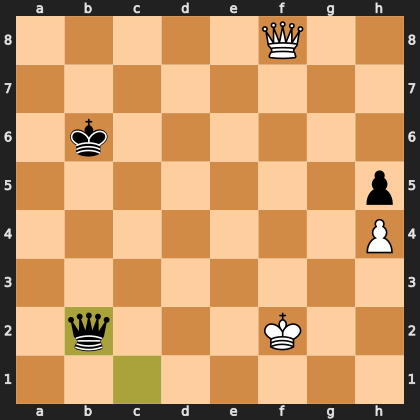

50. f8=Q  [Laya fine-tuned (laya_chess_v2) +rules: f8=Q 0.81, Kg2 0.48, Kg3 0.48]
50... Qb2+  [CLM (chess): Qb2+ 0.07, Qa2+ 0.06, Qg1+ 0.06]
51. Ke1  [Laya fine-tuned (laya_chess_v2) +rules: Ke1 0.42, Ke3 0.41, Kf1 0.41]
51... Qc1+  [CLM (chess): Qc1+ 0.05, Qe5+ 0.05, Qc3+ 0.05]
52. Kf2  [Laya fine-tuned (laya_chess_v2) +rules: Kf2 0.54, Ke2 0.49]
52... Qb2+  [CLM (chess): Qb2+ 0.09, Qc2+ 0.07, Qe1+ 0.06]
53. Ke1  [Laya fine-tuned (laya_chess_v2) +rules: Ke1 0.26, Kf3 0.26, Kf1 0.25]
53... Qc1+  [CLM (chess): Qc1+ 0.08, Qe5+ 0.05, Qc3+ 0.05]
54. Kf2  [Laya fine-tuned (laya_chess_v2) +rules: Kf2 0.32, Ke2 0.27]
54... Qb2+  [CLM (chess): Qb2+ 0.56, Qc2+ 0.03, Qe1+ 0.03]

Result: 1/2-1/2 - threefold_repetition


In [ ]:
import random, time
import chess, chess.svg
from IPython.display import display, SVG, clear_output
from laya_player import LayaPlayer, game_finished
from clm_player import CLMPlayer

RANDOM_OPENING_MOVES = 4   # both models are deterministic, so vary the start
SECONDS_PER_MOVE = 1.0     # slow down so you can follow along

laya = LayaPlayer(local_path="runs/laya_chess_v2", verbose=False)
clm = CLMPlayer(model="chess", verbose=False)
players = {chess.WHITE: laya, chess.BLACK: clm}   # swap these to switch colors

board, log = chess.Board(), []
for _ in range(RANDOM_OPENING_MOVES):
    move = random.choice(list(board.legal_moves))
    log.append(f"{board.fullmove_number}{'.' if board.turn else '...'} {board.san(move)}  (random opening)")
    board.push(move)

while not game_finished(board) and board.ply() < 300:
    mover = players[board.turn]
    move = mover.choose_move(board.copy())
    top = ", ".join(f"{s} {p:.2f}" for s, p in mover.last_scores[:3])
    log.append(f"{board.fullmove_number}{'.' if board.turn else '...'} {board.san(move)}  [{mover.name}: {top}]")
    board.push(move)
    clear_output(wait=True)
    print(f"White: {laya.name}   Black: {clm.name}")
    display(SVG(chess.svg.board(board, lastmove=move, size=420)))
    print("\n".join(log[-10:]))
    time.sleep(SECONDS_PER_MOVE)

outcome = board.outcome(claim_draw=True)
print("\nResult:", board.result(claim_draw=True), "-", outcome.termination.name.lower() if outcome else "move limit")

In [ ]:
# To save a single file for video
!python laya_arena.py --games 1 --player laya --player-laya-path runs/laya_chess_v2 --opponent clm --opponent-clm-model chess --log-dir runs/one_game

In [ ]:
# 12.5 Vs JEV

In [ ]:
import os
from google.colab import userdata
os.environ["TYPESAFE_API_KEY"] = userdata.get("TYPESAFE_API_KEY")
print("key loaded:", bool(os.environ["TYPESAFE_API_KEY"]))

key loaded: True


In [ ]:
!grep -c "strong_rules" jev_player.py

1


In [ ]:
!python -c "import chess, jev_player; print(jev_player.JevPlayer().choose_move(chess.Board()))"

[jev] using typesafe: https://api.typesafe.ai/v1/systemone (model jev-latest), cap 5000 requests this session
   [Jev (jev-latest)] 20 moves in 0.75s | top: e4 0.940, Nf3 0.900, d4 0.880, Nc3 0.840, c4 0.810 | spread 0.800 | session: 20 requests, 10,001 input tokens
e2e4


In [ ]:
!curl -s localhost:8700/health && echo " CLM server OK"

{"ok":true,"embedder":true,"models":["clm-latest","chess","clm-raw"],"cache":{"device":"cuda","reserved_mb":848.1,"hit_rate":null,"pools":{"512":{"dim":512,"capacity":362354,"used":0,"reserved_mb":742.1,"hits":0,"misses":0,"evictions":0,"hit_rate":null},"4096":{"dim":4096,"capacity":6470,"used":0,"reserved_mb":106.0,"hits":0,"misses":0,"evictions":0,"hit_rate":null}}}} CLM server OK


In [ ]:
#Fine-tuned CLM vs Jev:

In [ ]:
!python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent jev --rules --max-requests 80000 --log-dir runs/arena_clm_vs_jev

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_clm_vs_jev/
Command: python laya_arena.py --games 10 --player clm --player-clm-model chess --opponent jev --rules --max-requests 80000 --log-dir runs/arena_clm_vs_jev
[clm] using http://127.0.0.1:8700 (model: chess)
[jev] using typesafe: https://api.typesafe.ai/v1/systemone (model jev-latest), cap 80000 requests this session
Each game starts with 4 random moves
   [CLM (chess)] 28 moves in 0.39s | top: d4 0.074, Bxh8 0.072, e4 0.065, Nf3 0.058, e3 0.050 | spread 0.058
   [Jev (jev-late

In [ ]:
!python laya_arena.py --games 10 --player laya --player-laya-path runs/laya_chess_v2 --opponent jev --rules --max-requests 80000 --log-dir runs/arena_laya_v2_vs_jev

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Logging this run to runs/arena_laya_v2_vs_jev/
Command: python laya_arena.py --games 10 --player laya --player-laya-path runs/laya_chess_v2 --opponent jev --rules --max-requests 80000 --log-dir runs/arena_laya_v2_vs_jev
[laya] loaded Laya fine-tuned (laya_chess_v2) +rules on cuda in 30.9s (question: 'best_rules')
[jev] using typesafe: https://api.typesafe.ai/v1/systemone (model jev-latest), cap 80000 requests this session
Each game starts with 4 random moves
[laya] input is 395 tokens (checkpoint limit 512)
   [Laya

# Step 13: Tournoment - Jev vs Laya vs CLM

In [15]:
import os
from google.colab import userdata
os.environ["TYPESAFE_API_KEY"] = userdata.get("TYPESAFE_API_KEY")
print("key loaded:", bool(os.environ["TYPESAFE_API_KEY"]))

key loaded: True


In [21]:
!nohup vllm serve Qwen/Qwen3-8B --served-model-name qwen3-8b --runner pooling --max-model-len 2048 --port 8090 --gpu-memory-utilization 0.5 > /content/vllm.log 2>&1 &

In [23]:
!for i in $(seq 1 90); do curl -s localhost:8090/health >/dev/null && echo READY && break; pgrep -f "vllm serve" >/dev/null || { echo "SERVER STOPPED"; break; }; sleep 10; done; tail -3 /content/vllm.log

READY
(APIServer pid=26066) OSError: [Errno 98] Address already in use
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [25]:
!pkill -f clm-serve; sleep 2
!nohup clm-serve --model chess=/content/drive/MyDrive/laya_chess_clm/runs/chess/best_head.pt --no-ui > /content/clm.log 2>&1 &
!for i in $(seq 1 30); do curl -s localhost:8700/health >/dev/null && echo READY && break; sleep 5; done; tail -5 /content/clm.log

^C
READY
[clm] models ['clm-latest', 'chess', 'clm-raw'] on cuda
[clm] embedder http://127.0.0.1:8090/v1/embeddings (qwen3-8b) up; auth off
[clm] vector cache 848.1 MB reserved on cuda (362,354x512d + 6,470x4096d)
[clm] POST http://0.0.0.0:8700/v1/systemone


In [27]:
!curl -s -o /dev/null -w "Qwen3-8B server: %{http_code}\n" localhost:8090/health
!curl -s -o /dev/null -w "CLM server: %{http_code}\n" localhost:8700/health
!pgrep -fa "vllm serve|clm-serve" | grep -v pgrep

Qwen3-8B server: 200
CLM server: 200
24562 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen3-8B --served-model-name qwen3-8b --runner pooling --max-model-len 2048 --port 8090 --gpu-memory-utilization 0.5
26288 /usr/bin/python3 /usr/local/bin/clm-serve --model chess=/content/drive/MyDrive/laya_chess_clm/runs/chess/best_head.pt --no-ui


In [12]:
import importlib, tournament as T
importlib.reload(T)
T.run_all()

<module 'tournament' from '/content/drive/MyDrive/laya_chess_clm/tournament.py'>

In [29]:
T.show_table()

match                        W   D   L  unf  score  material  Jev $  how games ended
01_jev_vs_random             9   1   0    0    95%     +28.5   0.46  checkmate 9, insufficient_material 1
02_laya_base_vs_random       3   3   0    4    75%      +5.8   0.00  move limit 4, checkmate 3, insufficient_material 2, stalemate 1
03_clm_base_vs_random        0   2   4    4    17%     -21.2   0.00  checkmate 4, move limit 4, stalemate 1, threefold_repetition 1
04_jev_vs_laya_base         10   0   0    0   100%     +31.9   0.24  checkmate 10
05_jev_vs_clm_base          10   0   0    0   100%     +30.3   0.24  checkmate 10
06_laya_base_vs_clm_base     7   3   0    0    85%     +14.1   0.00  checkmate 7, threefold_repetition 3
07_jev_vs_laya_v2            3   6   1    0    60%      +1.6   0.44  insufficient_material 5, checkmate 4, fifty_moves 1
08_jev_vs_clm_ft             1   5   4    0    35%      -4.3   0.29  checkmate 5, insufficient_material 4, fifty_moves 1
09_laya_v2_vs_clm_ft         1   

In [21]:
# T.list_games(termination="checkmate")
# T.list_games("jev_vs_clm_ft", result="loss", game=9)
# T.list_games("05_jev_vs_clm_base", result="win", game=10)
T.list_games("03_clm_base_vs_random", result="loss", game=1)
# T.list_games("09", termination="repetition")

03_clm_base_vs_random      game  1: CLM (original) vs Random -> 0-1 (checkmate, 140 half-moves, material -20)

1 game(s)


[('03_clm_base_vs_random', 1)]

In [22]:
# picks = T.list_games(termination="checkmate")
# picks = T.list_games("jev_vs_clm_ft", result="loss")
# picks = T.list_games("jev_vs_clm_ft", result="loss", game=9)
# picks = T.list_games("05_jev_vs_clm_base", result="win", game=10)
picks = T.list_games("03_clm_base_vs_random", result="loss", game=1)
T.export_games(picks)

03_clm_base_vs_random      game  1: CLM (original) vs Random -> 0-1 (checkmate, 140 half-moves, material -20)

1 game(s)
Saved 1 game(s) to runs/tournament/picked_games.pgn


# Step 14: Shut down
Everything (models, reports, arena logs) is saved in your Drive folder. When done: **Runtime → Disconnect and delete runtime**.